# Turn-Taking Fusion Experiments

### Note that Early Fusion will only work for unimodal data -- or data collected at the same Hz!
#### Also please note you will have to configure a lot of the paths yourself
Thin driver for dyadic-fusion experiments on the turn-taking corpus. All heavy lifting (dataset classes, model classes, training helpers, τ-sweep) lives in `fusion_lib.py`. This notebook just:

1. Declares a modality registry (currently set up for CPC and OpenFace).
2. Declares a dict of experiments — each experiment is `{streams, fusion}` where `streams = [{modality, role}, ...]` and `fusion ∈ {'unimodal', 'early', 'neural_concat'}`.
3. Runs each experiment, collects results, and generates a τ-sweep curve.



## Section 0 — Setup

## init

In [24]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [25]:
cd '535_project_data'

[Errno 2] No such file or directory: '535_project_data'
/content


In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd

BASE = "C:\\Users\\Muichiro\\Documents\\USC\\project\\csci535-project\\turn_taking_analysis\\"

# Ensure fusion_lib is importable (same dir as this notebook).
THIS_DIR = Path(os.getcwd())
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

import torch
import numpy as np
from tqdm import tqdm

print('torch:', torch.__version__, ' device-available:',
      'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

torch: 2.6.0+cu124  device-available: cuda


In [2]:
import sys

SCRIPTS_DIR = f"{BASE}/scripts"
if SCRIPTS_DIR not in sys.path:
    sys.path.append(SCRIPTS_DIR)

In [3]:
import fusion_lib as fl
print(fl.__file__)

C:\Users\Muichiro\Documents\USC\project\csci535-project\turn_taking_analysis\scripts\fusion_lib.py


In [4]:
HIDDEN_SIZE       = 64
DROPOUT           = 0.3
NUM_LAYERS_EARLY  = 3            # GRU stack depth for EarlyFusion only
EPOCHS            = 30           # max epochs; early stopping may trigger earlier
BATCH_SIZE        = 32
LEARNING_RATE     = 1e-3
PATIENCE          = 4            # early-stop after N epochs w/o val-F1 gain
NUM_WORKERS       = 4
SEED              = 42

NUM_WORKERS = 0

TRAIN_TAU_MS = 400
MAX_SAMPLES_PER_SPLIT = None
MANIFEST_TYPE = 'cpc_available' # 'cpc_available_more' or 'all'

In [5]:
# COORDINATION_CSV_PATH = (
#     PROJ / "data" / "coordination" / "openface" / "all_coordination_features.csv"
# )

# COORDINATION_CSV_PATH = "/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/coordination/openface/all_coordination_features_tau_0400.csv"
CPC_DIR = f"{BASE}\\subset\\cpc\\"
OPENFACE_DIR = f"{BASE}\\subset\\openface\\"
COORD_DIR = f"{BASE}\\coordination\\openface\\"
LABELS_DIR = f"{BASE}\\model_input\\labels\\"
TRAIN_LABELS_PATH = f"{BASE}\\model_input\\labels\\labels_tau_0400.json"
MANIFEST_PATH = f"{BASE}\\manifests\\manifest_cpc_available.csv"#/data/spliced/manifests/manifest_cpc_available.csv" # manifest.csv, manifest_cpc_available.csv, manifest_cpc_available_more.csv
COORDINATION_CSV_PATH = f"{BASE}\\coordination\\openface\\all_coordination_features_tau_0400.csv"

RESULTS_DIR =  f"{BASE}/fusion_runs/coordination"

In [6]:
print(f'manifest:         {MANIFEST_PATH}')
print(f'train labels:     {TRAIN_LABELS_PATH}')
print(f'dry-run cap:      {MAX_SAMPLES_PER_SPLIT}')

manifest:         C:\Users\Muichiro\Documents\USC\project\csci535-project\turn_taking_analysis\\manifests\manifest_cpc_available.csv
train labels:     C:\Users\Muichiro\Documents\USC\project\csci535-project\turn_taking_analysis\\model_input\labels\labels_tau_0400.json
dry-run cap:      None


##init deprecated

In [ ]:
# # -----------------------------------------------------------------------------
# # Paths
# # -----------------------------------------------------------------------------
# PROJ = THIS_DIR.parents[0]     # .../turn_taking_analysis

# # First pass: POC manifest. Swap to 'manifests/manifest.csv' for full-dataset
# # runs (requires `build_labeled_windows_from_manifest.py` rerun to extend the
# # label files beyond the POC 46 file_ids).

# #MANIFEST_PATH = PROJ / 'manifests' / 'manifest_test.csv'
# MANIFEST_PATH = '/Users/kaitlinzareno/Desktop/csci535/csci535-project/turn_taking_analysis/manifests/manifest_cpc_available.csv' #local path

# #LABELS_DIR = PROJ / 'model_input' / 'labels'
# LABELS_DIR = '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/labels_tau/'
# TRAIN_TAU_MS = 400               # canonical training τ per spec §11.5
# TRAIN_LABELS_PATH = LABELS_DIR + f'labels_tau_{TRAIN_TAU_MS:04d}.json'

# # Dry-run / small-subset mode. Set to None to use all available samples.
# # For smoke tests, try MAX_SAMPLES_PER_SPLIT = 200 to verify plumbing end-
# # to-end in ~30 s before committing to a full run. Truncation is preceded
# # by a seed-deterministic shuffle per split so the subset is representative.
# MAX_SAMPLES_PER_SPLIT = None

# Model / training hyperparameters. Defaults match the CSCI-535 practicum
# (multimodal_fusion_practicum.ipynb): GRU_UNITS=64, EPOCHS=30, BATCH_SIZE=32,
# LR=1e-3, patience=4, dropout=0.3, num_layers=3 (EarlyFusion only).

## Section 1 — Modality registry

Each entry: `{dir, feature_dim, frame_rate_hz}`. `frame_rate_hz` is metadata (not consumed by the loader) — kept for documentation. Add new modalities by appending entries and referencing them in experiment configs.

The on-disk layout each modality must satisfy:

```
<modality.dir>/
  <interaction_id>_<participant_id>/
    NNNN.NN-NNNN.NN_<interaction_id>_<participant_id>.npy
    ...
```

## non-coordinatino

In [14]:
MODALITY_REGISTRY = fl.make_modality_registry({
    'cpc': {
        'dir': CPC_DIR,
        'feature_dim': 256,
        'frame_rate_hz': 100.0,
    },
    'openface': {
        'dir': OPENFACE_DIR,
        'feature_dim': 23,
        'frame_rate_hz': 30.0,
    },
})
for name, cfg in MODALITY_REGISTRY.items():
    print(f'  {name}: dim={cfg["feature_dim"]}  rate={cfg["frame_rate_hz"]} Hz  dir={cfg["dir"]}')

  cpc: dim=256  rate=100.0 Hz  dir=/content/drive/MyDrive/535_project_data/data/spliced/cpc
  openface: dim=23  rate=30.0 Hz  dir=/content/drive/MyDrive/535_project_data/data/spliced/openface_new


## adding coordination

In [7]:
MODALITY_REGISTRY = fl.make_modality_registry_coordination({
    "cpc": {
        "dir": CPC_DIR,
        "feature_dim": 256,
        "frame_rate_hz": 100.0,
    },
    "openface": {
        "dir": OPENFACE_DIR,
        "feature_dim": 23,
        "frame_rate_hz": 30.0,
    },
    'coordination_openface': {
        'kind':          'coordination',
        'feature_dim':   fl.COORDINATION_FEATURE_DIM,
        'frame_rate_hz': 0.0,
    },
})

for name, cfg in MODALITY_REGISTRY.items():
    print(f'  {name}: dim={cfg["feature_dim"]}  rate={cfg["frame_rate_hz"]} Hz  dir={cfg["dir"]}')

  cpc: dim=256  rate=100.0 Hz  dir=C:\Users\Muichiro\Documents\USC\project\csci535-project\turn_taking_analysis\\subset\cpc\
  openface: dim=23  rate=30.0 Hz  dir=C:\Users\Muichiro\Documents\USC\project\csci535-project\turn_taking_analysis\\subset\openface\
  coordination_openface: dim=19  rate=0.0 Hz  dir=


## Section 2 — Load manifest + label sanity

In [8]:
manifest_rows = fl.load_manifest(str(MANIFEST_PATH))
print(f'manifest rows: {len(manifest_rows)}')
print(f'splits:        {dict((sp, sum(1 for r in manifest_rows if r["split"] == sp)) for sp in ("train", "val", "test"))}')

# Cross-check label coverage against the manifest.
train_labels = fl.load_labels(str(TRAIN_LABELS_PATH))
samples = fl.enumerate_samples(manifest_rows, train_labels)
summary = fl.summarize_samples(samples)
print(f'\ntotal training-usable samples at τ={TRAIN_TAU_MS} ms: {summary["total"]}')
print(f'per-split: {summary["per_split"]}')
for split, dist in summary['per_split_class'].items():
    print(f'  {split:5s}  class distribution: {dist}')

manifest rows: 222
splits:        {'train': 155, 'val': 33, 'test': 34}

total training-usable samples at τ=400 ms: 63598
per-split: {'val': 9729, 'train': 43684, 'test': 10185}
  val    class distribution: {'HOLD': 8667, 'BACKCHANNEL': 739, 'YIELD': 323}
  train  class distribution: {'HOLD': 39429, 'YIELD': 1323, 'BACKCHANNEL': 2932}
  test   class distribution: {'BACKCHANNEL': 719, 'HOLD': 9191, 'YIELD': 275}


## Section 3 — Experiment definitions

Each experiment declares its streams (modality + role) and fusion family.

**Fusion families supported:**
- `unimodal` — single stream, single GRU + FC.
- `early` — N streams concatenated on the feature axis, single 3-layer GRU.
- `neural_concat` — exactly 2 streams, two parallel GRUs, concat final hidden states, FC head.

**Roles supported per stream:**
- `speaker` — the floor holder (perspective participant).
- `listener` — the co-participant (resolved via manifest).

Add / remove experiments by editing `EXPERIMENTS` below.

## non-coordinaton

In [ ]:
# EXPERIMENTS = {
#     'cpc_both_early': {
#         'streams': [
#             {'modality': 'cpc', 'role': 'speaker'},
#             {'modality': 'cpc', 'role': 'listener'},
#         ],
#         'fusion':  'early',
#     },
#     'cpc_both_neural_concat': {
#         'streams': [
#             {'modality': 'cpc', 'role': 'speaker'},
#             {'modality': 'cpc', 'role': 'listener'},
#         ],
#         'fusion':  'neural_concat',
#     },
#     'cpc_speaker_of_listener': {
#         'streams': [
#             {'modality': 'cpc', 'role': 'speaker'},
#             {'modality': 'openface', 'role': 'listener'},
#         ],
#         'fusion':  'neural_concat',
#     },
#     'cpc_speaker_of_dyad': {
#         'streams': [
#             {'modality': 'cpc',      'role': 'speaker'},
#             {'modality': 'openface', 'role': 'listener'},
#             {'modality': 'openface', 'role': 'speaker'},
#         ],
#         'fusion': 'neural_concat',
#     },
#     'full_dyad': {
#         'streams': [
#             {'modality': 'cpc',      'role': 'speaker'},
#             {'modality': 'cpc',      'role': 'listener'},
#             {'modality': 'openface', 'role': 'speaker'},
#             {'modality': 'openface', 'role': 'listener'},
#         ],
#         'fusion': 'neural_concat',
#     }
# }
EXPERIMENTS = {
'cpc_speaker': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
        ],
        'fusion': 'unimodal',
    },
    'openface_speaker': {
        'streams': [
            {"modality": "openface", "role": "speaker"},
        ],
        'fusion': 'unimodal',
    },
    'full_dyad': {
        'streams': [
            {'modality': 'cpc',    'role': 'speaker'},
            {'modality': 'cpc',    'role': 'listener'},
            {'modality': 'openface', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
        ],
        'fusion': 'neural_concat',
    }
}

print(f'configured experiments: {len(EXPERIMENTS)}')
for name, cfg in EXPERIMENTS.items():
    print(f'  {name:30s}  fusion={cfg["fusion"]:14s}  streams={cfg["streams"]}')

## experiments with coordination

In [9]:
EXPERIMENTS_COORDINATION ={

     'cpc_speaker_plus_coordination': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'coordination_openface', 'role': 'speaker'},
        ],
        'fusion': 'neural_concat',
    },

    #ONLY TEST OPENFSACE AND COORD LOCAL
        "openface_with_coord_neural_concat": {
        "streams": [
            {"modality": "openface", "role": "speaker"},
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        "fusion": "neural_concat",
    },

    #ONLY TEST OPENFSACE AND COORD LOCAL
      "openface_BOTH_with_coord_neural_concat": {
        "streams": [
            {"modality": "openface", "role": "speaker"},
            {"modality": "openface", "role": "listener"},
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        "fusion": "neural_concat",
    },

    'cpc_speaker_of_listener_coord': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        'fusion':  'neural_concat',
    },

     'cpc_speaker_both_faces_coord': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        'fusion':  'neural_concat',
    },

    'full_dyad_plus_coordination': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'cpc', 'role': 'listener'},
            {'modality': 'openface', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
            {'modality': 'coordination_openface', 'role': 'speaker'},
        ],
        'fusion': 'neural_concat',
    },
}

print(f'configured experiments: {len(EXPERIMENTS_COORDINATION)}')
for name, cfg in EXPERIMENTS_COORDINATION.items():
    print(f'  {name:30s}  fusion={cfg["fusion"]:14s}  streams={cfg["streams"]}')

configured experiments: 6
  cpc_speaker_plus_coordination   fusion=neural_concat   streams=[{'modality': 'cpc', 'role': 'speaker'}, {'modality': 'coordination_openface', 'role': 'speaker'}]
  openface_with_coord_neural_concat  fusion=neural_concat   streams=[{'modality': 'openface', 'role': 'speaker'}, {'modality': 'coordination_openface', 'role': 'speaker'}]
  openface_BOTH_with_coord_neural_concat  fusion=neural_concat   streams=[{'modality': 'openface', 'role': 'speaker'}, {'modality': 'openface', 'role': 'listener'}, {'modality': 'coordination_openface', 'role': 'speaker'}]
  cpc_speaker_of_listener_coord   fusion=neural_concat   streams=[{'modality': 'cpc', 'role': 'speaker'}, {'modality': 'openface', 'role': 'listener'}, {'modality': 'coordination_openface', 'role': 'speaker'}]
  cpc_speaker_both_faces_coord    fusion=neural_concat   streams=[{'modality': 'cpc', 'role': 'speaker'}, {'modality': 'openface', 'role': 'speaker'}, {'modality': 'openface', 'role': 'listener'}, {'modali

## Section 4 — Run experiments

Trains one model per experiment at the canonical τ (default 400 ms), keeps the best-val-macro-F1 checkpoint, and evaluates on test. Early stopping kicks in after `PATIENCE` epochs without a val-F1 improvement (caps training well under `EPOCHS`). Results are accumulated in `results` and reused in Section 5 for the τ-sweep (input features are τ-invariant; only labels change).

## non-coordination

In [10]:
results = {}
for name, cfg in EXPERIMENTS.items():
    res = fl.run_experiment(
        name=name,
        streams=cfg['streams'],
        fusion=cfg['fusion'],
        modality_registry=MODALITY_REGISTRY,
        manifest_rows=manifest_rows,
        labels_path=str(TRAIN_LABELS_PATH),
        hidden_size=HIDDEN_SIZE,
        dropout=DROPOUT,
        num_layers_early=NUM_LAYERS_EARLY,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        seed=SEED,
        max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
    )
    results[name] = res
    print()

print('=== summary at training τ ===')
for name, res in results.items():
    print(f'  {name:30s}  test macro-F1 = {res["test_eval"]["macro_f1"]:.4f}  '
          f'per-class = {res["test_eval"]["per_class_f1"]}')

NameError: name 'EXPERIMENTS' is not defined

## Run coordination


In [10]:
BATCH_SIZE=128

In [11]:
import importlib
import fusion_lib as fl
importlib.reload(fl)

<module 'fusion_lib' from 'C:\\Users\\Muichiro\\Documents\\USC\\project\\csci535-project\\turn_taking_analysis\\scripts\\fusion_lib.py'>

In [12]:
import json
import time
from pathlib import Path
from tqdm.auto import tqdm
import torch

RUN_ID = time.strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("/content/drive/MyDrive/535_project_data/fusion_runs/summary") / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

def make_json_safe_result(res):
    safe = {}
    for k, v in res.items():
        if k == "model_state":
            continue  # save separately with torch.save
        safe[k] = v
    return safe

coordination_results = {}

for name, cfg in tqdm(EXPERIMENTS_COORDINATION.items()):
    print(f"\nRunning {name}")

    try:
        coord_res = fl.run_experiment_coordination(
            name=name,
            streams=cfg["streams"],
            fusion=cfg["fusion"],
            modality_registry=MODALITY_REGISTRY,
            manifest_rows=manifest_rows,
            labels_path=str(TRAIN_LABELS_PATH),
            hidden_size=HIDDEN_SIZE,
            dropout=DROPOUT,
            num_layers_early=NUM_LAYERS_EARLY,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            patience=PATIENCE,
            num_workers=NUM_WORKERS,
            seed=SEED,
            max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
            coordination_csv_path=str(COORDINATION_CSV_PATH),
        )

        coordination_results[name] = coord_res

        # Save JSON summary
        json_path = OUT_DIR / f"{name}_results.json"
        with open(json_path, "w") as f:
            json.dump(make_json_safe_result(coord_res), f, indent=2, default=str)

        # Save model weights separately
        model_path = OUT_DIR / f"{name}_model_state.pt"
        torch.save(coord_res["model_state"], model_path)

        print(f"Saved {name} to:")
        print(json_path)
        print(model_path)

    except Exception as e:
        print(f"FAILED: {name}")
        print(repr(e))

        # Save partial results
        partial_path = OUT_DIR / "partial_results.json"
        with open(partial_path, "w") as f:
            json.dump(
                {k: make_json_safe_result(v) for k, v in coordination_results.items()},
                f,
                indent=2,
                default=str,
            )

        raise

print("=== summary at training τ ===")
for name, coord_res in coordination_results.items():
    print(
        f'{name:30s} test macro-F1 = {coord_res["test_eval"]["macro_f1"]:.4f} '
        f'per-class = {coord_res["test_eval"]["per_class_f1"]}'
    )

print("Run saved to:", OUT_DIR)

  0%|          | 0/6 [00:00<?, ?it/s]


Running cpc_speaker_plus_coordination
=== Experiment: cpc_speaker_plus_coordination ===
  streams:   [{'modality': 'cpc', 'role': 'speaker'}, {'modality': 'coordination_openface', 'role': 'speaker'}]
  fusion:    neural_concat
  device:    cuda
  samples:   total=63598  per_split={'train': 43684, 'val': 9729, 'test': 10185}
             train class-dist: {'HOLD': 39429, 'YIELD': 1323, 'BACKCHANNEL': 2932}
             val   class-dist: {'HOLD': 8667, 'BACKCHANNEL': 739, 'YIELD': 323}
             test  class-dist: {'BACKCHANNEL': 719, 'HOLD': 9191, 'YIELD': 275}
  model:     NeuralConcatFusion  (86,595 params)
  class_w:   [0.36930516362190247, 11.006299018859863, 4.966348171234131]
  epochs:    up to 30 (patience=4)
  dropout:   0.3  num_layers_early: 3



Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

train epoch 1:   0%|          | 0/342 [00:00<?, ?it/s]

val epoch 1:   0%|          | 0/77 [00:00<?, ?it/s]

...

val epoch 4:   0%|          | 0/77 [00:00<?, ?it/s]

  epoch  4/30  train_loss=0.5350  val_loss=0.6300  val_macroF1=0.6318   (no_improve=3/4, 133.0s)


train epoch 5:   0%|          | 0/342 [00:00<?, ?it/s]

val epoch 5:   0%|          | 0/77 [00:00<?, ?it/s]

  epoch  5/30  train_loss=0.5075  val_loss=0.6605  val_macroF1=0.6155   (no_improve=4/4, 136.8s)
  early stopping at epoch 5 (best val macroF1=0.6402)

  final test eval (full_dyad_plus_coordination):
    macro_f1 = 0.5820
    per-class F1 = {'HOLD': 0.9415073115860518, 'YIELD': 0.324468085106383, 'BACKCHANNEL': 0.4801641586867305}
Saved full_dyad_plus_coordination to:
\content\drive\MyDrive\535_project_data\fusion_runs\summary\20260427_110040\full_dyad_plus_coordination_results.json
\content\drive\MyDrive\535_project_data\fusion_runs\summary\20260427_110040\full_dyad_plus_coordination_model_state.pt
=== summary at training τ ===
cpc_speaker_plus_coordination  test macro-F1 = 0.5139 per-class = {'HOLD': 0.8985356253979279, 'YIELD': 0.3557894736842105, 'BACKCHANNEL': 0.2874475034997667}
openface_with_coord_neural_concat test macro-F1 = 0.3702 per-class = {'HOLD': 0.7820118039517578, 'YIELD': 0.10501474926253686, 'BACKCHANNEL': 0.22351797862001946}
openface_BOTH_with_coord_neural_concat 

## BUGGY

In [ ]:
EXPERIMENTS_COORDINATION_EXTRA ={
        "coord_only_openface": {
        "streams": [
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        "fusion": "unimodal",
    },
}

In [ ]:
import json
import time
from pathlib import Path
from tqdm.auto import tqdm
import torch

RUN_ID = time.strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("/content/drive/MyDrive/535_project_data/fusion_runs") / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

def make_json_safe_result(res):
    safe = {}
    for k, v in res.items():
        if k == "model_state":
            continue  # save separately with torch.save
        safe[k] = v
    return safe

coordination_results = {}

for name, cfg in tqdm(EXPERIMENTS_COORDINATION.items()):
    print(f"\nRunning {name}")

    try:
        coord_res = fl.run_experiment_coordination(
            name=name,
            streams=cfg["streams"],
            fusion=cfg["fusion"],
            modality_registry=MODALITY_REGISTRY,
            manifest_rows=manifest_rows,
            labels_path=str(TRAIN_LABELS_PATH),
            hidden_size=HIDDEN_SIZE,
            dropout=DROPOUT,
            num_layers_early=NUM_LAYERS_EARLY,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            patience=PATIENCE,
            num_workers=NUM_WORKERS,
            seed=SEED,
            max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
            coordination_csv_path=str(COORDINATION_CSV_PATH),
        )

        coordination_results[name] = coord_res

        # Save JSON summary
        json_path = OUT_DIR / f"{name}_results.json"
        with open(json_path, "w") as f:
            json.dump(make_json_safe_result(coord_res), f, indent=2, default=str)

        # Save model weights separately
        model_path = OUT_DIR / f"{name}_model_state.pt"
        torch.save(coord_res["model_state"], model_path)

        print(f"Saved {name} to:")
        print(json_path)
        print(model_path)

    except Exception as e:
        print(f"FAILED: {name}")
        print(repr(e))

        # Save partial results
        partial_path = OUT_DIR / "partial_results.json"
        with open(partial_path, "w") as f:
            json.dump(
                {k: make_json_safe_result(v) for k, v in coordination_results.items()},
                f,
                indent=2,
                default=str,
            )

        raise

print("=== summary at training τ ===")
for name, coord_res in coordination_results.items():
    print(
        f'{name:30s} test macro-F1 = {coord_res["test_eval"]["macro_f1"]:.4f} '
        f'per-class = {coord_res["test_eval"]["per_class_f1"]}'
    )

print("Run saved to:", OUT_DIR)

## Section 5 — τ-sweep

Evaluates each trained model against every per-τ label file. Features are τ-invariant, so the model weights don't change — only the label-to-basename mapping swaps. The τ-sweep uses the same class-weighted CrossEntropyLoss that was used during training (weights derived from the train-split at training-τ), so per-τ loss numbers are comparable to the training history.

## pull and use cached coordination results

In [18]:
from pathlib import Path
import json

RUN_DIR = Path("C:\\Users\\Muichiro\\Documents\\USC\\project\\csci535-project\\turn_taking_analysis\\subset\\saved_models")

In [19]:
coordination_results = {}

for p in RUN_DIR.glob("*.json"):
    if p.name == "run_index.json" or "partial" in p.name:
        continue

    with open(p) as f:
        data = json.load(f)

    exp_name = data.get("name") or data.get("experiment_name") or p.stem
    coordination_results[exp_name] = data

print("Loaded experiments:", list(coordination_results.keys()))

Loaded experiments: []


In [39]:
import torch
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/535_project_data/fusion_runs/summary/20260427_073531")

for name, res in coordination_results.items():
    candidates = [
        RUN_DIR / f"{name}_model_state.pt",
        RUN_DIR / f"{name}.pt",
    ]

    found = None
    for p in candidates:
        if p.exists():
            found = p
            break

    if found is None:
        print(f"No model_state file found for {name}")
        continue

    DEVICE = res["device"] if isinstance(res["device"], torch.device) else torch.device(res["device"])

    res["model_state"] = torch.load(found, map_location=DEVICE)
    print(f"Loaded model_state for {name}: {found}")

Loaded model_state for cpc_speaker_plus_coordination: /content/drive/MyDrive/535_project_data/fusion_runs/summary/20260427_073531/cpc_speaker_plus_coordination_model_state.pt
Loaded model_state for openface_with_coord_neural_concat: /content/drive/MyDrive/535_project_data/fusion_runs/summary/20260427_073531/openface_with_coord_neural_concat_model_state.pt
Loaded model_state for full_dyad_plus_coordination: /content/drive/MyDrive/535_project_data/fusion_runs/summary/20260427_073531/full_dyad_plus_coordination_model_state.pt


In [40]:
import fusion_lib as fl
print(fl.__file__)

/content/drive/MyDrive/535_project_data/scripts/fusion_lib.py


## run tau curves

In [13]:
RUN_ID = time.strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("\\model_input\\fusion_runs\\tau_sweeps") / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
tau_curves = {}

for name, res in coordination_results.items():
    print(f'\n=== τ-sweep: {name} ===')

    try:
        tau_res = fl.sweep_tau_coordination_safe(
            experiment_result=res,
            modality_registry=MODALITY_REGISTRY,
            manifest_rows=manifest_rows,
            labels_dir=str(LABELS_DIR),  # ⚠️ fix: should be DIR, not TRAIN_LABELS_PATH
            tau_grid_ms=fl.DEFAULT_TAU_GRID_MS,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED,
            max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
        )

        tau_curves[name] = tau_res

        # Save immediately
        tau_path = OUT_DIR / f"{name}_tau_curves.json"
        with open(tau_path, "w") as f:
            json.dump(tau_res, f, indent=2)

        print(f"Saved τ results → {tau_path}")

    except Exception as e:
        print(f"FAILED τ-sweep: {name}")
        print(repr(e))

        # Save partial τ results
        partial_tau_path = OUT_DIR / "partial_tau_curves.json"
        with open(partial_tau_path, "w") as f:
            json.dump(tau_curves, f, indent=2)

        raise

    print()


=== τ-sweep: cpc_speaker_plus_coordination ===
  τ=100ms: kept 11713/11713, dropped 0 missing-file samples
  τ= 100ms  n=11713  loss=0.7743  macroF1=0.4388  per-class={'HOLD': 0.8830665715159548, 'YIELD': 0.11909262759924387, 'BACKCHANNEL': 0.3141818181818182}
  τ=200ms: kept 11069/11069, dropped 0 missing-file samples
  τ= 200ms  n=11069  loss=0.7414  macroF1=0.4757  per-class={'HOLD': 0.8907500266723567, 'YIELD': 0.2274678111587983, 'BACKCHANNEL': 0.3089430894308943}
  τ=400ms: kept 10185/10185, dropped 0 missing-file samples
  τ= 400ms  n=10185  loss=0.7848  macroF1=0.5139  per-class={'HOLD': 0.8985356253979279, 'YIELD': 0.3557894736842105, 'BACKCHANNEL': 0.2874475034997667}
  τ=500ms: kept 9924/9924, dropped 0 missing-file samples
  τ= 500ms  n= 9924  loss=0.8108  macroF1=0.5150  per-class={'HOLD': 0.8962719952281539, 'YIELD': 0.3629268292682926, 'BACKCHANNEL': 0.2857142857142857}
  τ=800ms: kept 9470/9470, dropped 0 missing-file samples
  τ= 800ms  n= 9470  loss=0.9814  macroF1=0

## Section 6 — τ-curve plot

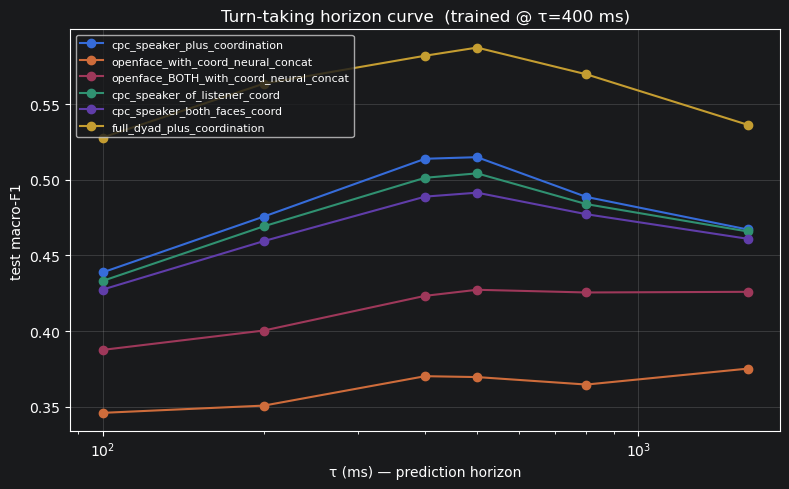

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for name, curve in tau_curves.items():
    taus = sorted(curve.keys())
    f1s = [curve[t]['macro_f1'] for t in taus]
    ax.plot(taus, f1s, marker='o', label=name)

ax.set_xlabel('τ (ms) — prediction horizon')
ax.set_ylabel('test macro-F1')
ax.set_title(f'Turn-taking horizon curve  (trained @ τ={TRAIN_TAU_MS} ms)')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## Section 7 — Save Results Data
### (it is excessive, but we won't regret having too much to make figs from I think)

Write a JSON of results (minus `model_state`, which is a tensor dict) for later comparison across notebook runs.

In [16]:
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1" # get rid of debugger output

In [17]:
## Section 7 — Persist detailed results for offline analysis & figure-making

# Why so much detail: the in-memory `results` and `tau_curves` dicts only carry
# scalar summaries (macro-F1, per-class F1). To make confusion-matrix heatmaps,
# ROC/AUC curves, calibration plots, per-interaction breakdowns, or any kind of
# error analysis later, we need the per-sample softmax probabilities, the
# predicted/true class per sample, sample identifiers, and full per-class
# precision/recall/F1/support — at every τ we evaluate.
#
# Output layout:
#   model_input/fusion_runs/<run_id>/run_index.json    — overall run metadata
#   model_input/fusion_runs/<run_id>/<exp_name>.json   — full per-experiment results

import json, os, sys, time
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import torch

from pathlib import Path

RUN_ID = time.strftime('%Y%m%d_%H%M%S')
#OUT_DIR = PROJ / 'model_input' / 'fusion_runs' / RUN_ID

OUT_DIR = Path(f'{RESULTS_DIR}/{MANIFEST_TYPE}/s7/{RUN_ID}')
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = fl.resolve_device('auto')

LABELS_DIR = Path(LABELS_DIR)

OPENFACE_DIR = Path(OPENFACE_DIR)

MODALITY_REGISTRY["openface"]["dir"] = str(OPENFACE_DIR)

print(MODALITY_REGISTRY["openface"])

# test_rel = Path("V00_S1295_I00000280_P0518/0000.00-0002.00_V00_S1295_I00000280_P0518.npy")
# test_full = Path(MODALITY_REGISTRY["openface"]["dir"]) / test_rel

# print(test_full)
# print(test_full.exists())

# ---------------------------------------------------------------------------
# Helpers — kept local to Section 7 so we don't have to touch fusion_lib.
# ---------------------------------------------------------------------------

def _inference_with_probs(model, loader, device):
    """Run inference, capture per-sample softmax probs + argmax preds + labels."""
    model.eval()
    probs_chunks, preds, labels = [], [], []
    with torch.inference_mode():
        for streams, ys in loader:
            streams = [t.to(device) for t in streams]
            logits = model(streams)
            p = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_chunks.append(p)
            preds.extend(p.argmax(-1).tolist())
            labels.extend(ys.cpu().tolist())
    probs = np.concatenate(probs_chunks, axis=0) if probs_chunks else np.zeros((0, fl.NUM_CLASSES), dtype=np.float32)
    return probs, preds, labels


def _confusion_matrix(preds, labels, num_classes=fl.NUM_CLASSES):
    """Rows = true class, cols = predicted class. Counts."""
    cm = [[0] * num_classes for _ in range(num_classes)]
    for p, y in zip(preds, labels):
        if 0 <= y < num_classes and 0 <= p < num_classes:
            cm[y][p] += 1
    return cm


def _per_class_metrics(preds, labels, num_classes=fl.NUM_CLASSES):
    """precision, recall, F1, support, plus raw tp/fp/fn for downstream stats."""
    out = {}
    for c in range(num_classes):
        tp = sum(1 for p, y in zip(preds, labels) if p == c and y == c)
        fp = sum(1 for p, y in zip(preds, labels) if p == c and y != c)
        fn = sum(1 for p, y in zip(preds, labels) if p != c and y == c)
        support = sum(1 for y in labels if y == c)
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        out[fl.CLASS_NAMES[c]] = {
            'precision': prec, 'recall': rec, 'f1': f1,
            'support': support, 'tp': tp, 'fp': fp, 'fn': fn,
        }
    return out


def _aggregate_macro(per_class: dict) -> dict:
    """Macro precision/recall/F1 (unweighted mean over classes) + weighted F1
    (mean over classes weighted by support — useful when you want a single
    number that respects class imbalance)."""
    classes = list(per_class.values())
    n = len(classes) or 1
    macro_p  = sum(c['precision'] for c in classes) / n
    macro_r  = sum(c['recall']    for c in classes) / n
    macro_f1 = sum(c['f1']        for c in classes) / n
    total_support = sum(c['support'] for c in classes) or 1
    weighted_f1 = sum(c['f1'] * c['support'] for c in classes) / total_support
    return {
        'macro_precision': macro_p,
        'macro_recall':    macro_r,
        'macro_f1':        macro_f1,
        'weighted_f1':     weighted_f1,
    }


def _grouped_metrics(samples, preds, labels, key_fn):
    """Slice (samples, preds, labels) by `key_fn(sample)` and compute per-group
    n / macro-F1 / per-class metrics / confusion matrix. Used for per-interaction,
    per-participant, per-relationship breakdowns."""
    groups = defaultdict(lambda: {'preds': [], 'labels': []})
    for s, p, y in zip(samples, preds, labels):
        k = key_fn(s)
        groups[k]['preds'].append(p)
        groups[k]['labels'].append(y)
    out = {}
    for k, d in groups.items():
        per_class = _per_class_metrics(d['preds'], d['labels'])
        agg = _aggregate_macro(per_class)
        out[k] = {
            'n_samples': len(d['preds']),
            **agg,
            'per_class': per_class,
            'confusion_matrix': _confusion_matrix(d['preds'], d['labels']),
        }
    return out


# Manifest-derived lookup for relationship / participant slicing.
_iid_to_relationship = {r['interaction_id']: r.get('relationship', 'unknown')
                        for r in manifest_rows}
_iid_to_relationship_detail = {r['interaction_id']: r.get('relationship_detail', 'unknown')
                                for r in manifest_rows}

# ---------------------------------------------------------------------------
# Per-experiment full re-evaluation across τ-grid WITH PARTIAL SAVES
# ---------------------------------------------------------------------------

detailed_results = {}

print("coordination_results keys:", list(coordination_results.keys()))

expected = set(EXPERIMENTS_COORDINATION.keys())
actual = set(coordination_results.keys())

print("expected:", expected)
print("actual:", actual)
print("missing:", expected - actual)

# Optional: use smaller grid for debugging
TAU_GRID = fl.DEFAULT_TAU_GRID_MS
# TAU_GRID = (200, 400, 800)

for exp_name in EXPERIMENTS_COORDINATION.keys():

    if exp_name not in coordination_results:
        print(f"SKIPPING {exp_name}: not found in coordination_results")
        continue

    exp_res = coordination_results[exp_name]

    if "model_state" not in exp_res:
        print(f"SKIPPING {exp_name}: no model_state")
        continue

    print(f"\nSaving detailed results for: {exp_name}")

    cfg = exp_res["config"]
    stream_cfg = cfg["streams"]
    fusion = cfg["fusion"]
    stream_dims = exp_res["stream_dims"]

    model = fl.build_model(
        fusion,
        stream_dims,
        hidden_size=cfg["hidden_size"],
        dropout=cfg.get("dropout", 0.3),
        num_layers_early=cfg.get("num_layers_early", 3),
    ).to(DEVICE)

    model.load_state_dict(exp_res["model_state"])

    train_labels_for_weights = fl.load_labels(cfg["labels_path"])
    train_samples_for_weights = [
        s for s in fl.enumerate_samples(manifest_rows, train_labels_for_weights)
        if s["split"] == "train"
    ]

    class_weights_used = (
        fl.compute_class_weights(train_samples_for_weights)
        .cpu()
        .tolist()
    )

    criterion = torch.nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights_used, dtype=torch.float32, device=DEVICE)
    )

    history = exp_res["train_history"]
    best_epoch_entry = max(history, key=lambda h: h["val_macro_f1"]) if history else None
    n_params = sum(int(p.numel()) for p in model.parameters())

    coordination_lookup = fl.load_coordination_features(
        str(COORDINATION_CSV_PATH),
        feature_cols=fl.COORDINATION_FEATURE_COLUMNS,
    )

    tau_results = {}

    detailed_results[exp_name] = {
        "experiment_name": exp_name,
        "config": cfg,
        "stream_dims": stream_dims,
        "device": exp_res["device"],
        "n_params": n_params,
        "class_weights_used": class_weights_used,
        "samples_summary": exp_res["samples_summary"],
        "train_history": history,
        "best_epoch": best_epoch_entry["epoch"] if best_epoch_entry else None,
        "best_val_macro_f1": best_epoch_entry["val_macro_f1"] if best_epoch_entry else None,
        "epochs_completed": len(history),
        "tau_results": tau_results,
    }

    out_path = OUT_DIR / f"{exp_name}.json"
    partial_path = OUT_DIR / f"{exp_name}_partial.json"

    for tau_ms in TAU_GRID:
        try:
            print(f"\nτ={tau_ms}")

            labels_path = LABELS_DIR / f"labels_tau_{tau_ms:04d}.json"
            if not labels_path.exists():
                print(f"  labels missing, skipping: {labels_path}")
                continue

            labels_dict = fl.load_labels(str(labels_path))
            samples = fl.enumerate_samples(manifest_rows, labels_dict)
            test_samples = [s for s in samples if s["split"] == "test"]

            if not test_samples:
                print(f"  no test samples for τ={tau_ms}, skipping")
                continue

            loader = fl.make_dataloader_coordination(
                test_samples,
                stream_cfg,
                MODALITY_REGISTRY,
                batch_size=BATCH_SIZE,
                shuffle=False,
                num_workers=NUM_WORKERS,
                coordination_lookup=coordination_lookup,
                coordination_feature_dim=len(fl.COORDINATION_FEATURE_COLUMNS),
                missing_coordination="zeros",
            )

            probs, preds, labels = _inference_with_probs(model, loader, DEVICE)

            per_class = _per_class_metrics(preds, labels)
            agg = _aggregate_macro(per_class)

            with torch.inference_mode():
                test_loss = 0.0
                n = 0

                for streams_batch, ys in loader:
                    streams_batch = [t.to(DEVICE) for t in streams_batch]
                    ys = ys.to(DEVICE)

                    logits = model(streams_batch)
                    test_loss += criterion(logits, ys).item() * ys.size(0)
                    n += ys.size(0)

                test_loss = test_loss / max(n, 1)

            sample_records = [
                {
                    "basename": s["basename"],
                    "interaction_id": s["interaction_id"],
                    "speaker_file_id": s["speaker_file_id"],
                    "listener_file_id": s["listener_file_id"],
                    "window_start_s": s["start_s"],
                    "window_end_s": s["end_s"],
                    "split": s["split"],
                    "label": int(y),
                    "pred": int(p),
                    "probs": [float(x) for x in row],
                    "correct": int(p) == int(y),
                }
                for s, p, y, row in zip(test_samples, preds, labels, probs)
            ]

            tau_results[str(tau_ms)] = {
                "n_test_samples": len(test_samples),
                "test_loss": test_loss,
                **agg,
                "per_class": per_class,
                "confusion_matrix": _confusion_matrix(preds, labels),
                "class_distribution_test": dict(Counter(labels)),
                "per_interaction": _grouped_metrics(
                    test_samples,
                    preds,
                    labels,
                    key_fn=lambda s: s["interaction_id"],
                ),
                "per_speaker": _grouped_metrics(
                    test_samples,
                    preds,
                    labels,
                    key_fn=lambda s: s["speaker_file_id"],
                ),
                "per_relationship": _grouped_metrics(
                    test_samples,
                    preds,
                    labels,
                    key_fn=lambda s: _iid_to_relationship.get(
                        s["interaction_id"], "unknown"
                    ),
                ),
                "per_relationship_detail": _grouped_metrics(
                    test_samples,
                    preds,
                    labels,
                    key_fn=lambda s: _iid_to_relationship_detail.get(
                        s["interaction_id"], "unknown"
                    ),
                ),
                "sample_records": sample_records,
            }

            detailed_results[exp_name]["tau_results"] = tau_results

            with open(out_path, "w") as f:
                json.dump(detailed_results[exp_name], f, indent=2, default=str)

            print(f"  [saved τ={tau_ms}] → {out_path}")

        except Exception as e:
            print(f"  FAILED at τ={tau_ms}")
            print(repr(e))

            detailed_results[exp_name]["tau_results"] = tau_results

            with open(partial_path, "w") as f:
                json.dump(detailed_results[exp_name], f, indent=2, default=str)

            print(f"  [partial save] → {partial_path}")
            raise

    with open(out_path, "w") as f:
        json.dump(detailed_results[exp_name], f, indent=2, default=str)

    print(f"  wrote final {out_path}")
    print(f"  size: {out_path.stat().st_size / 1024:.1f} KB")


# ---------------------------------------------------------------------------
# Run-level index
# ---------------------------------------------------------------------------

run_index = {
    "run_id": RUN_ID,
    "timestamp": datetime.now().isoformat(),
    "manifest_path": str(MANIFEST_PATH),
    "train_labels_path": str(TRAIN_LABELS_PATH),
    "train_tau_ms": TRAIN_TAU_MS,
    "tau_grid_ms": list(TAU_GRID),
    "modality_registry": MODALITY_REGISTRY,
    "global_hyperparams": {
        "hidden_size": HIDDEN_SIZE,
        "dropout": DROPOUT,
        "num_layers_early": NUM_LAYERS_EARLY,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "seed": SEED,
        "max_samples_per_split": MAX_SAMPLES_PER_SPLIT,
    },
    "experiments": list(detailed_results.keys()),
    "experiment_summary": {
        name: {
            "fusion": d["config"]["fusion"],
            "streams": d["config"]["streams"],
            "n_params": d["n_params"],
            "best_epoch": d["best_epoch"],
            "epochs_run": d["epochs_completed"],
            "test_macro_f1_at_train_tau": d["tau_results"]
                .get(str(TRAIN_TAU_MS), {})
                .get("macro_f1"),
        }
        for name, d in detailed_results.items()
    },
    "environment": {
        "torch_version": torch.__version__,
        "python_version": sys.version.split()[0],
        "device": str(DEVICE),
        "platform": sys.platform,
    },
}

with open(OUT_DIR / "run_index.json", "w") as f:
    json.dump(run_index, f, indent=2, default=str)

print(f'  wrote {OUT_DIR / "run_index.json"}')

print(f"\nRun directory: {OUT_DIR}")
print("Files:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

{'kind': 'spliced', 'dir': 'C:\\Users\\Muichiro\\Documents\\USC\\project\\csci535-project\\turn_taking_analysis\\subset\\openface', 'feature_dim': 23, 'frame_rate_hz': 30.0}
coordination_results keys: ['cpc_speaker_plus_coordination', 'openface_with_coord_neural_concat', 'openface_BOTH_with_coord_neural_concat', 'cpc_speaker_of_listener_coord', 'cpc_speaker_both_faces_coord', 'full_dyad_plus_coordination']
expected: {'cpc_speaker_plus_coordination', 'openface_with_coord_neural_concat', 'openface_BOTH_with_coord_neural_concat', 'cpc_speaker_of_listener_coord', 'full_dyad_plus_coordination', 'cpc_speaker_both_faces_coord'}
actual: {'cpc_speaker_plus_coordination', 'openface_with_coord_neural_concat', 'openface_BOTH_with_coord_neural_concat', 'cpc_speaker_of_listener_coord', 'full_dyad_plus_coordination', 'cpc_speaker_both_faces_coord'}
missing: set()

Saving detailed results for: cpc_speaker_plus_coordination

τ=100
  [saved τ=100] → C:\Users\Muichiro\Documents\USC\project\csci535-projec

In [23]:
import torch
from pathlib import Path

MODELS_DIR = "C:\\Users\\Muichiro\\Documents\\USC\\project\\csci535-project\\turn_taking_analysis\\subset\\saved_models\\"
# MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, res in coordination_results.items():
    save_path = MODELS_DIR / f'{name}.pt'
    torch.save({
        'model_state': res['model_state'],
        'config': res['config'],
        'stream_dims': res['stream_dims'],
        'test_eval': res['test_eval'],
        'train_history': res['train_history'],
    }, save_path)
    print(f'Saved {name} → {save_path}')